<a href="https://colab.research.google.com/github/minakumarithapa12/CN7030_Machine-Learning-Big-Data/blob/main/Bitcoin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assessment Lab — Distributed Bitcoin Price Forecasting using PySpark

This notebook adapts the Guided Lab pipeline (AAPL daily stock forecasting) to the **Bitcoin Historical Data** dataset (1-minute resolution, `Timestamp, Open, High, Low, Close, Volume`).

**Pipeline stages**
1. Environment setup (PySpark on Colab)
2. Load Bitcoin data into a Spark DataFrame
3. Preprocess & resample to daily OHLCV (chronological, avoids the 7.6M-row minute-level data being unwieldy while preserving the same daily granularity as the Guided Lab)
4. Feature engineering — lag features & rolling statistics via window functions
5. Build the supervised learning target (next-day Close) with a time-based train/test split
6. Train Linear Regression and Gradient Boosted Trees (Spark ML)
7. Evaluate with RMSE / MAE
8. Visualise actual vs. predicted prices over time


## 1. Environment Setup

In [1]:
!pip install pyspark -q

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import matplotlib.pyplot as plt
import pandas as pd

spark = SparkSession.builder \
    .appName("BitcoinForecasting") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

spark

## 2. Load the Bitcoin Dataset

Upload `btcusd_1-min_data.csv` (unzipped from `Bitcoin.zip`) to your Colab session, or mount Google Drive and point `DATA_PATH` at it. The raw file has ~7.6 million rows of 1-minute OHLCV data, so we let Spark handle the load in a distributed fashion.

In [8]:

DATA_PATH = "btcusd_1-min_data.csv"  # update path if using Google Drive

schema_cols = ["Timestamp", "Open", "High", "Low", "Close", "Volume"]

df_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

df_raw.printSchema()
df_raw.show(5)
print("Row count:", df_raw.count())

root
 |-- Timestamp: integer (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)

+----------+----+----+----+-----+------+
| Timestamp|Open|High| Low|Close|Volume|
+----------+----+----+----+-----+------+
|1325376060|4.58|4.58|4.58| 4.58|   0.0|
|1325376120|4.58|4.58|4.58| 4.58|   0.0|
|1325376180|4.58|4.58|4.58| 4.58|   0.0|
|1325376240|4.58|4.58|4.58| 4.58|   0.0|
|1325376300|4.58|4.58|4.58| 4.58|   0.0|
+----------+----+----+----+-----+------+
only showing top 5 rows
Row count: 154229


## 3. Preprocessing & Resampling to Daily OHLCV

The Guided Lab worked with **daily** AAPL data. The Bitcoin dataset is minute-level, so we:
- convert the Unix `Timestamp` to a proper date/time
- drop rows with zero/erroneous trading activity if needed
- aggregate to **daily bars** (Open = first trade of day, High = max, Low = min, Close = last trade of day, Volume = sum) to keep the same time-aware, chronologically-ordered structure as the Guided Lab


In [9]:
df = df_raw.withColumn("datetime", F.to_timestamp(F.col("Timestamp").cast("long")))
df = df.withColumn("date", F.to_date("datetime"))

# Daily OHLCV aggregation using window-ordered first/last within each day
day_window = Window.partitionBy("date").orderBy("datetime")
day_window_desc = Window.partitionBy("date").orderBy(F.col("datetime").desc())

df_daily = (
    df.withColumn("rn_first", F.row_number().over(day_window))
      .withColumn("rn_last", F.row_number().over(day_window_desc))
      .groupBy("date")
      .agg(
          F.max(F.when(F.col("rn_first") == 1, F.col("Open"))).alias("Open"),
          F.max("High").alias("High"),
          F.min("Low").alias("Low"),
          F.max(F.when(F.col("rn_last") == 1, F.col("Close"))).alias("Close"),
          F.sum("Volume").alias("Volume")
      )
      .orderBy("date")
)

df_daily = df_daily.filter(F.col("Close").isNotNull())
df_daily.show(5)
print("Daily rows:", df_daily.count())

+----------+----+----+----+-----+------------------+
|      date|Open|High| Low|Close|            Volume|
+----------+----+----+----+-----+------------------+
|2012-01-01|4.58| 5.0|4.58|  5.0|            21.602|
|2012-01-02| 5.0| 5.0| 5.0|  5.0|            19.048|
|2012-01-03| 5.0|5.32| 5.0| 5.29|       88.03728092|
|2012-01-04|5.29|5.57|4.93| 5.57|107.23326023000001|
|2012-01-05|5.57|6.65|5.57| 6.65|       94.80182926|
+----------+----+----+----+-----+------------------+
only showing top 5 rows
Daily rows: 108


## 4. Feature Engineering — Lag Features & Rolling Statistics

Using Spark window functions (ordered by `date`) to generate:
- Lag features: `Close` from 1, 2, 3, 7 days ago
- Rolling statistics: 7-day and 14-day moving average & standard deviation of `Close`

This mirrors the Guided Lab's approach of capturing temporal dependencies and market trends.

In [10]:
w = Window.orderBy("date")

roll7  = Window.orderBy("date").rowsBetween(-6, 0)
roll14 = Window.orderBy("date").rowsBetween(-13, 0)

df_feat = (
    df_daily
    .withColumn("Close_lag1", F.lag("Close", 1).over(w))
    .withColumn("Close_lag2", F.lag("Close", 2).over(w))
    .withColumn("Close_lag3", F.lag("Close", 3).over(w))
    .withColumn("Close_lag7", F.lag("Close", 7).over(w))
    .withColumn("Close_roll_mean7", F.avg("Close").over(roll7))
    .withColumn("Close_roll_std7", F.stddev("Close").over(roll7))
    .withColumn("Close_roll_mean14", F.avg("Close").over(roll14))
    .withColumn("Close_roll_std14", F.stddev("Close").over(roll14))
    .withColumn("Volume_roll_mean7", F.avg("Volume").over(roll7))
)

df_feat.select(
    "date", "Close", "Close_lag1", "Close_lag7",
    "Close_roll_mean7", "Close_roll_std7"
).show(10)

+----------+-----+----------+----------+------------------+-------------------+
|      date|Close|Close_lag1|Close_lag7|  Close_roll_mean7|    Close_roll_std7|
+----------+-----+----------+----------+------------------+-------------------+
|2012-01-01|  5.0|      NULL|      NULL|               5.0|               NULL|
|2012-01-02|  5.0|       5.0|      NULL|               5.0|                0.0|
|2012-01-03| 5.29|       5.0|      NULL| 5.096666666666667|0.16743157806499148|
|2012-01-04| 5.57|      5.29|      NULL|             5.215| 0.2733130073743291|
|2012-01-05| 6.65|      5.57|      NULL|             5.502| 0.6840102338415708|
|2012-01-06|  6.0|      6.65|      NULL|             5.585| 0.6446937257333907|
|2012-01-07|  6.8|       6.0|      NULL| 5.758571428571428| 0.7464902002354883|
|2012-01-08|  7.0|       6.8|       5.0| 6.044285714285714| 0.7892793578714099|
|2012-01-09|  6.3|       7.0|       5.0|6.2299999999999995| 0.6417683902052722|
|2012-01-10| 7.14|       6.3|      5.29|

## 5. Target Variable & Time-Based Train/Test Split

**Target:** next day's `Close` price (`F.lead`) — this is what we're forecasting.

**Split:** strictly chronological (e.g. last ~20% of dates as the test set), to avoid data leakage — the same principle as the Guided Lab.

In [11]:
df_model = df_feat.withColumn("target_next_close", F.lead("Close", 1).over(w))

# Drop rows with nulls introduced by lag/lead/rolling windows
feature_cols = [
    "Open", "High", "Low", "Volume",
    "Close_lag1", "Close_lag2", "Close_lag3", "Close_lag7",
    "Close_roll_mean7", "Close_roll_std7",
    "Close_roll_mean14", "Close_roll_std14",
    "Volume_roll_mean7"
]

df_model = df_model.dropna(subset=feature_cols + ["target_next_close"])

# Chronological split — last 20% of dates reserved for testing
dates_sorted = [r["date"] for r in df_model.select("date").orderBy("date").collect()]
split_date = dates_sorted[int(len(dates_sorted) * 0.8)]
print("Split date:", split_date)

train_df = df_model.filter(F.col("date") < split_date)
test_df  = df_model.filter(F.col("date") >= split_date)

print("Train rows:", train_df.count(), "| Test rows:", test_df.count())

Split date: 2012-03-28
Train rows: 80 | Test rows: 20


In [12]:
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

train_vec = assembler.transform(train_df).select("date", "features", "target_next_close")
test_vec  = assembler.transform(test_df).select("date", "features", "target_next_close")

train_vec.show(3, truncate=False)

+----------+----------------------------------------------------------------------------------------------------------------------------------------------+-----------------+
|date      |features                                                                                                                                      |target_next_close|
+----------+----------------------------------------------------------------------------------------------------------------------------------------------+-----------------+
|2012-01-08|[6.8,7.0,6.8,5.0,6.8,6.0,6.65,5.0,6.044285714285714,0.7892793578714099,5.913749999999999,0.8187086957956589,49.75699644428572]                |6.3              |
|2012-01-09|[7.0,7.0,6.23,66.86932290000001,7.0,6.8,6.0,5.0,6.2299999999999995,0.6417683902052722,5.956666666666666,0.7765790365442529,56.58861400142858] |7.14             |
|2012-01-10|[6.3,7.14,6.24,62.28998018000001,6.3,7.0,6.8,5.29,6.494285714285714,0.5666820726197109,6.074999999999999,0.82224962416

## 6. Model Training — Linear Regression & Gradient Boosted Trees

In [13]:
lr = LinearRegression(featuresCol="features", labelCol="target_next_close")
lr_model = lr.fit(train_vec)

lr_preds = lr_model.transform(test_vec)
lr_preds.select("date", "target_next_close", "prediction").show(10)

+----------+-----------------+------------------+
|      date|target_next_close|        prediction|
+----------+-----------------+------------------+
|2012-03-28|             4.84| 4.892577218120796|
|2012-03-29|             4.88| 4.886441452659857|
|2012-03-30|              4.9| 4.832401833996509|
|2012-03-31|             4.89| 4.846768965553635|
|2012-04-01|             5.04| 4.800934320637457|
|2012-04-02|             4.99|4.8293621238630875|
|2012-04-03|             5.01|4.9330081256650296|
|2012-04-04|              5.0| 4.908781397328269|
|2012-04-05|             4.99| 4.901438029594761|
|2012-04-06|              4.7| 4.828425292971323|
+----------+-----------------+------------------+
only showing top 10 rows


In [15]:
gbt = GBTRegressor(featuresCol="features", labelCol="target_next_close", maxIter=10)
gbt_model = gbt.fit(train_vec)

gbt_preds = gbt_model.transform(test_vec)
gbt_preds.select("date", "target_next_close", "prediction").show(10)

+----------+-----------------+-----------------+
|      date|target_next_close|       prediction|
+----------+-----------------+-----------------+
|2012-03-28|             4.84|4.967416321828734|
|2012-03-29|             4.88|4.991388239482944|
|2012-03-30|              4.9|4.937239387789179|
|2012-03-31|             4.89|4.919214245281386|
|2012-04-01|             5.04|4.808550573077038|
|2012-04-02|             4.99|4.874233273599018|
|2012-04-03|             5.01|4.797408492553191|
|2012-04-04|              5.0|4.864090034787617|
|2012-04-05|             4.99|4.797408492553191|
|2012-04-06|              4.7|4.815774223272649|
+----------+-----------------+-----------------+
only showing top 10 rows


## 7. Evaluation — RMSE & MAE

In [16]:
evaluator_rmse = RegressionEvaluator(labelCol="target_next_close", predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol="target_next_close", predictionCol="prediction", metricName="mae")

results = {}
for name, preds in [("Linear Regression", lr_preds), ("Gradient Boosted Trees", gbt_preds)]:
    rmse = evaluator_rmse.evaluate(preds)
    mae  = evaluator_mae.evaluate(preds)
    results[name] = {"RMSE": rmse, "MAE": mae}
    print(f"{name}: RMSE = {rmse:.2f}, MAE = {mae:.2f}")

results

Linear Regression: RMSE = 0.11, MAE = 0.10
Gradient Boosted Trees: RMSE = 0.14, MAE = 0.12


{'Linear Regression': {'RMSE': 0.11371730835457292,
  'MAE': 0.10014080532387135},
 'Gradient Boosted Trees': {'RMSE': 0.13529735969511658,
  'MAE': 0.11637290746882352}}

## 8. Visualisation — Actual vs. Predicted Close Price

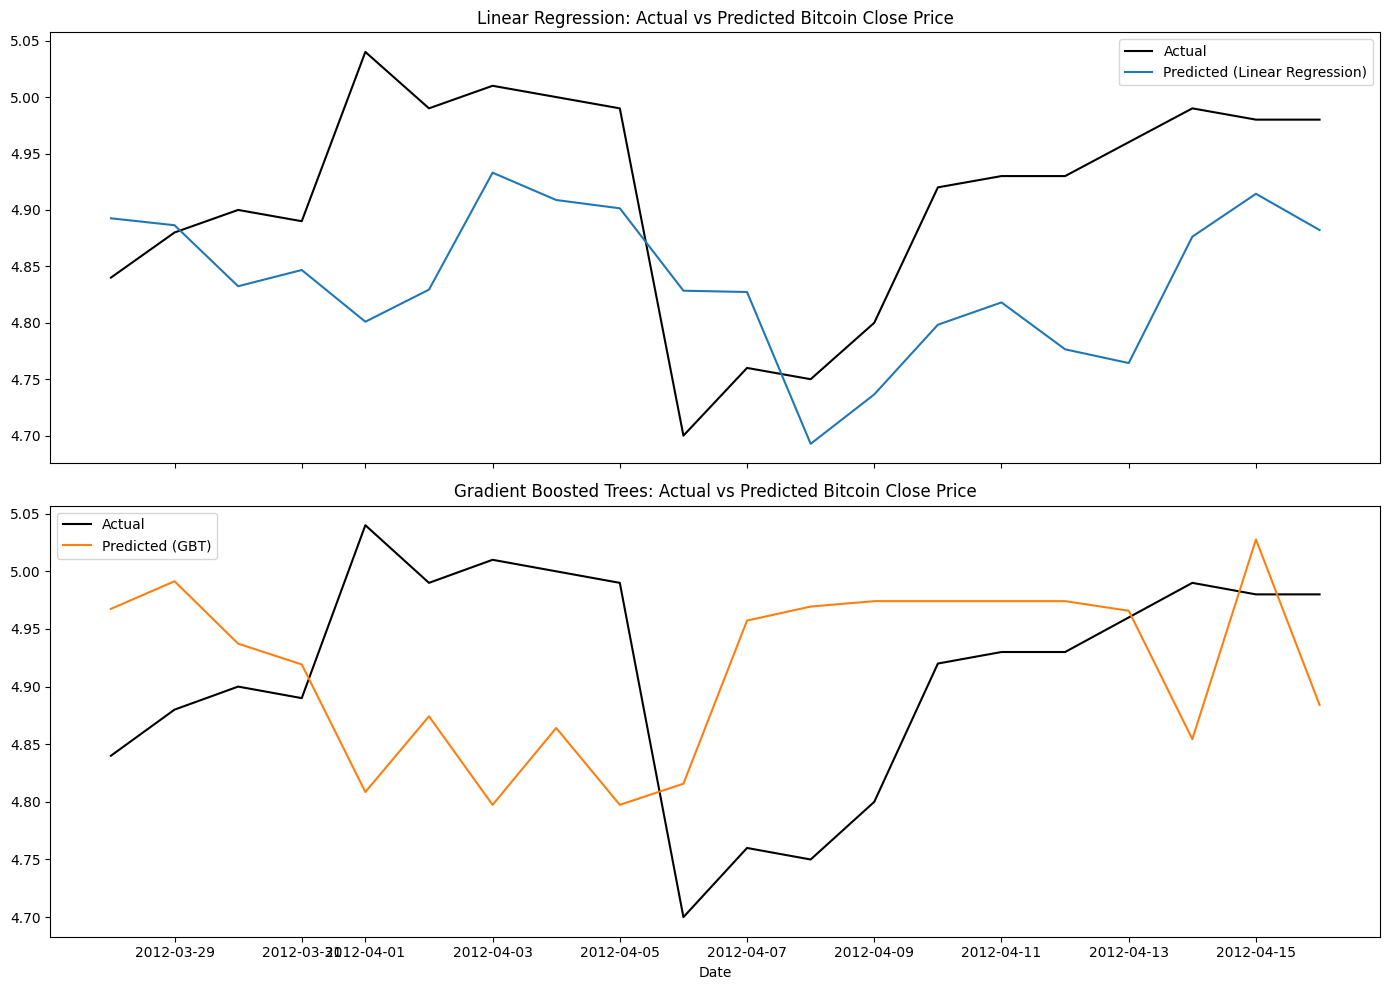

In [17]:
lr_pd  = lr_preds.select("date", "target_next_close", "prediction").orderBy("date").toPandas()
gbt_pd = gbt_preds.select("date", "target_next_close", "prediction").orderBy("date").toPandas()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(lr_pd["date"], lr_pd["target_next_close"], label="Actual", color="black")
axes[0].plot(lr_pd["date"], lr_pd["prediction"], label="Predicted (Linear Regression)", color="tab:blue")
axes[0].set_title("Linear Regression: Actual vs Predicted Bitcoin Close Price")
axes[0].legend()

axes[1].plot(gbt_pd["date"], gbt_pd["target_next_close"], label="Actual", color="black")
axes[1].plot(gbt_pd["date"], gbt_pd["prediction"], label="Predicted (GBT)", color="tab:orange")
axes[1].set_title("Gradient Boosted Trees: Actual vs Predicted Bitcoin Close Price")
axes[1].legend()

plt.xlabel("Date")
plt.tight_layout()
plt.show()